# Geographical map of coffee importers and coffee producers

In [49]:
# All notebooks start with the cell below to initialize database engine
from dotenv import load_dotenv
from sqlalchemy import create_engine, Engine
import pandas as pd
import plotly.graph_objects as go
import webbrowser, os

load_dotenv("../.env")

# start psql engine to grab data from database
def get_engine() -> Engine:
    '''
    Depending on .env, it will load localhost or online DB
    priority is online DB
    '''
    DATABASE_URL = os.environ.get("DATABASE_URL")

    if not DATABASE_URL:
        DB_USER = os.environ.get("DB_USER")
        DB_PASSWORD = os.environ.get("DB_PASSWORD")
        DB_HOST = os.environ.get("DB_HOST", "localhost")
        DB_PORT = os.environ.get("DB_PORT", "5432")
        DB_NAME = os.environ.get("DB_NAME")

        if not all([DB_USER, DB_PASSWORD, DB_NAME]):
            raise RuntimeError(
                "Set either DATABASE_URL, or DB_USER/DB_PASSWORD/DB_NAME in .env"
            )

        DATABASE_URL = f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"

    else:
        DATABASE_URL = f"postgresql+psycopg2://{DATABASE_URL}"

    return create_engine(DATABASE_URL)

engine = get_engine()

## Where are the coffee-producing countries, and what type do they grow, as well as the countries that do not produce coffee but imports and then exports coffee to other countries?
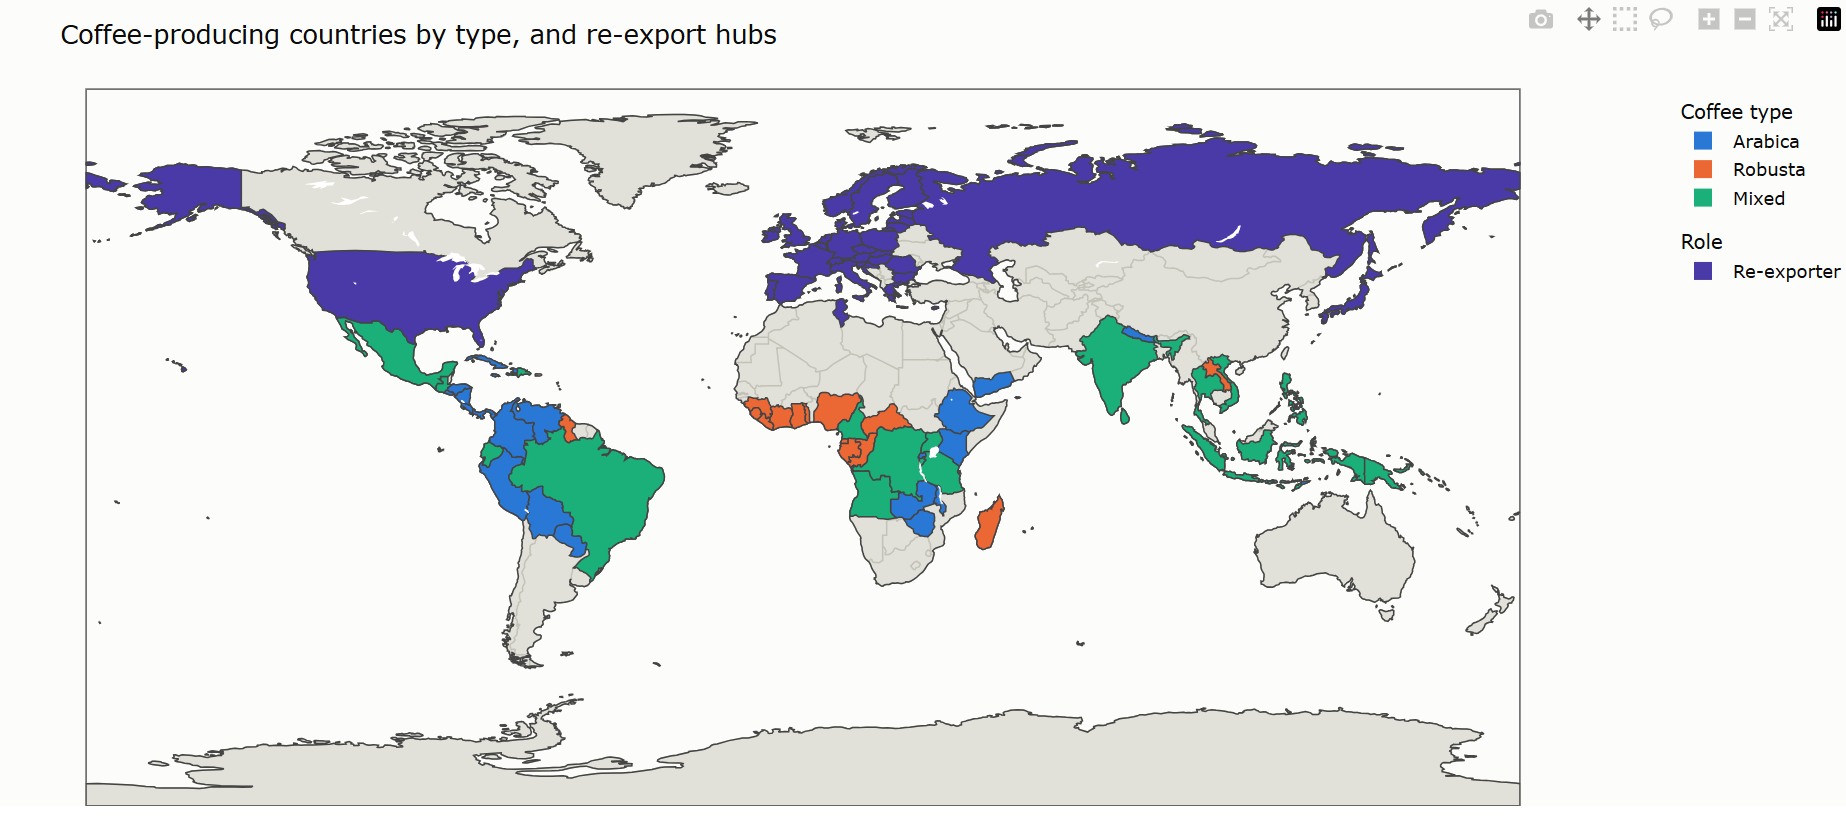

In [50]:
# extract coffee_production and coffee_re_export tables with all columns from proesgres database
production = pd.read_sql("SELECT * FROM coffee_production", engine)
re_export = pd.read_sql("SELECT * FROM coffee_re_export", engine)

# collapse Arabica/Robusta into "mixed" in new column category
production["category"] = production["coffee_type"].mask(production["coffee_type"].str.contains("/"), "Mixed")

production.head()

,country_code,country,coffee_type,1990,1991,1992,1993,1994,1995,1996,...,2012,2013,2014,2015,2016,2017,2018,2019,total_production,category
0,AGO,Angola,Robusta/Arabica,3000000,4740000,4680000,1980000,4620000,3720000,4260000,...,1980000,2100000,2340000,2460000,2700000,2100000,2520000,3120000,8.208000e+07,Mixed
1,BOL,Bolivia,Arabica,7380000,6240000,7200000,3060000,7020000,8520000,7500000,...,6300000,7200000,6000000,5040000,4680000,5040000,4980000,4860000,2.070000e+08,Arabica
2,BRA,Brazil,Arabica/Robusta,1637160000,1637580000,2076180000,1690020000,1691520000,1083600000,1751820000,...,3325080000,3281340000,3198300000,3172260000,3407280000,3164400000,3907860000,3492660000,7.508298e+10,Mixed
3,BDI,Burundi,Arabica/Robusta,29220000,40020000,37200000,23580000,39840000,26040000,24060000,...,24360000,9780000,14880000,16140000,11760000,12120000,12240000,16320000,6.236400e+08,Mixed
4,ECU,Ecuador,Arabica/Robusta,90240000,127440000,71100000,124140000,142560000,113280000,119580000,...,49680000,39960000,38640000,38640000,38700000,37440000,29760000,33540000,1.900380e+09,Mixed


In [51]:
#colour codes
BLUE, ORANGE, AQUA, VIOLET, GREEN, GREY = "#2a78d6", "#eb6834", "#1baf7a", "#4a3aa7", "#008300", "#e1e0d9"

fig = go.Figure()

# role map layer creation for producers
# trace index 0 = Producer
fig.add_trace(go.Choropleth(
    locations=production["country_code"],
    z=[1] * len(production),
    colorscale=[[0, GREEN], [1, GREEN]],
    showscale=False,
    name="Producer",
    legendgroup="role",
    legendgrouptitle_text="Role of Countries",
    showlegend=True,
    text=production["country"],
    customdata=production["total_production"],
    hovertemplate="%{text}<br>Production: %{customdata:,.0f}<extra></extra>",
))
# role map layer creation for re-exporters
# traceindex 1 = re-exporter
fig.add_trace(go.Choropleth(
    locations=re_export["country_code"],
    z=[1] * len(re_export),
    colorscale=[[0, VIOLET], [1, VIOLET]],
    showscale=False,
    name="Re-exporter",
    legendgroup="role",
    showlegend=True,
    text=re_export["country"],
    customdata=re_export["total_re_export"],
    hovertemplate="%{text}<br>Re-export volume: %{customdata:,.0f}<extra></extra>",
))

# pair coffee type to specific colour in the map
type_traces = [("Arabica", BLUE), ("Robusta", ORANGE), ("Mixed", AQUA)]

# coffee type map layer creation for producers: trace index 2 = arabica, index 3 = robusta, index 4 = mixed
# a loop that creates a new map layer for each coffee type
for type_name, color in type_traces:
    subset = production[production["category"] == type_name]
    fig.add_trace(go.Choropleth(
        locations=subset["country_code"],
        z=[1] * len(subset),
        colorscale=[[0, color], [1, color]],
        showscale=False,
        name=type_name,
        legendgroup="type",
        legendgrouptitle_text="Coffee type of Producers",
        showlegend=True,
        text=subset["country"],
        customdata=subset["total_production"],
        hovertemplate="%{text}<br>Production: %{customdata:,.0f}<extra></extra>",
    ))

# set map's background colours, margins, legend behaviours and fonts
fig.update_layout(
    title="Map showing coffee re-exporting countries as well as coffee producing countries by coffee type",
    template="plotly_white",
    margin=dict(l=0, r=0, t=60, b=0),
    legend=dict(groupclick="toggleitem"),
)

# set map's geography to show country separating lines and land colour to grey
fig.update_geos(
    landcolor=GREY,
    showcountries=True,
)

# When "Producer" is clicked, also toggle the 3 coffee-type traces (index 2,3,4) and re-export (index 1)
# this is custom behavior created using JavaScript as Plotly's legend doesn't do on its own.
CASCADE_JS = """
var gd = document.getElementsByClassName('plotly-graph-div')[0];
gd.on('plotly_legendclick', function(evt) {
    var idx = evt.curveNumber;
    if (gd.data[idx].name === 'Producer') {
        var goingVisible = (gd.data[idx].visible === 'legendonly');
        var newState = goingVisible ? true : 'legendonly';
        Plotly.restyle(gd, {visible: newState}, [2, 3, 4]);
    }
    return true;
});
"""

# saves the whole plotly map fig in a HTML file
fig.write_html("coffee_map.html", post_script=CASCADE_JS)
webbrowser.open("file://" + os.path.abspath("coffee_map.html"))

True